In [1]:
%config InlineBackend.figure_format='retina'
import sys
sys.path.append('../../')

In [ ]:
from zstar.core.strategy.core_strategy import CoreStrategy
from zstar.core.data_loader import YahooData, DataLoaderConfigModel
from zstar.core.backtest import BacktesterEngine, BacktestConfigModel

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
class BasicStrategy(CoreStrategy):
    def calculate_indicators(self, data: pd.DataFrame) -> pd.DataFrame:
        data["SMA20"] = data["close"].rolling(window=10).mean()
        data["SMA50"] = data["close"].rolling(window=20).mean()

        return data

    
    def long_entry_signals(self, data: pd.DataFrame) -> pd.DataFrame:
        data['long_entry'] = (
            (data['SMA20'] > data['SMA50']) &
            (data['SMA20'].shift(1) <= data['SMA50'].shift(1))
        )

        return data

    
    def short_entry_signals(self, data: pd.DataFrame) -> pd.DataFrame:
        data['short_entry'] = (
            (data['SMA20'] < data['SMA50']) &
            (data['SMA20'].shift(1) >= data['SMA50'].shift(1))
        )

        return data

    
    def long_exit_signals(self, data: pd.DataFrame) -> pd.DataFrame:
        data['long_exit'] = (
            (data['SMA20'] < data['SMA50']) &
            (data['SMA20'].shift(1) >= data['SMA50'].shift(1))
        )

        return data
    

    def short_exit_signals(self, data: pd.DataFrame) -> pd.DataFrame:
        data['short_exit'] = (
            (data['SMA20'] > data['SMA50']) &
            (data['SMA20'].shift(1) <= data['SMA50'].shift(1))
        )

        return data


    def position_size(self, balance: float, entry_price: float) -> float:
        return balance / entry_price

In [4]:
data_handler = YahooData(DataLoaderConfigModel(symbol="AAPL", start_date="2020-01-01"))
strategy = BasicStrategy()
config = BacktestConfigModel(
    initial_balance=10000.0,
    entry_fee_pct=0.01,
    exit_fee_pct=0.01,
    slippage_pct=0.005,
    slippage_seed=42
)
backtester = BacktesterEngine(strategy, data_handler, config)

In [5]:
report = backtester.run_backtest()

In [6]:
report.kpis()

{'initial_balance': 10000.0,
 'final_balance': -0.47687602552832686,
 'net_pnl': -10000.476876025528,
 'total_return_pct': -100.00476876025527,
 'total_trades': 35,
 'total_fees': 57.30025236223918,
 'gross_profit': 5495.966049379635,
 'gross_loss': 10727.205794100737,
 'win_rate_pct': 31.428571428571427,
 'avg_trade_pnl': -149.4639927063172,
 'avg_win': 499.63327721633044,
 'avg_loss': -446.9669080875307,
 'profit_factor': 0.5123390149186899,
 'expectancy': -149.4639927063172,
 'max_drawdown_pct': -56.90425159903758,
 'sharpe_ratio': -0.664535430615943,
 'best_trade': 948.3919342986758,
 'worst_trade': -1175.75852010976,
 'median_trade': -239.3313387212633,
 'avg_trade_duration_minutes': 35547.42857142857,
 'buy_and_hold_final_balance': 34479.77208394056,
 'buy_and_hold_return_pct': 244.7977208394056,
 'buy_and_hold_max_drawdown_pct': -33.43370956600401,
 'return_diff_vs_buy_and_hold_pct': -344.8024895996609}

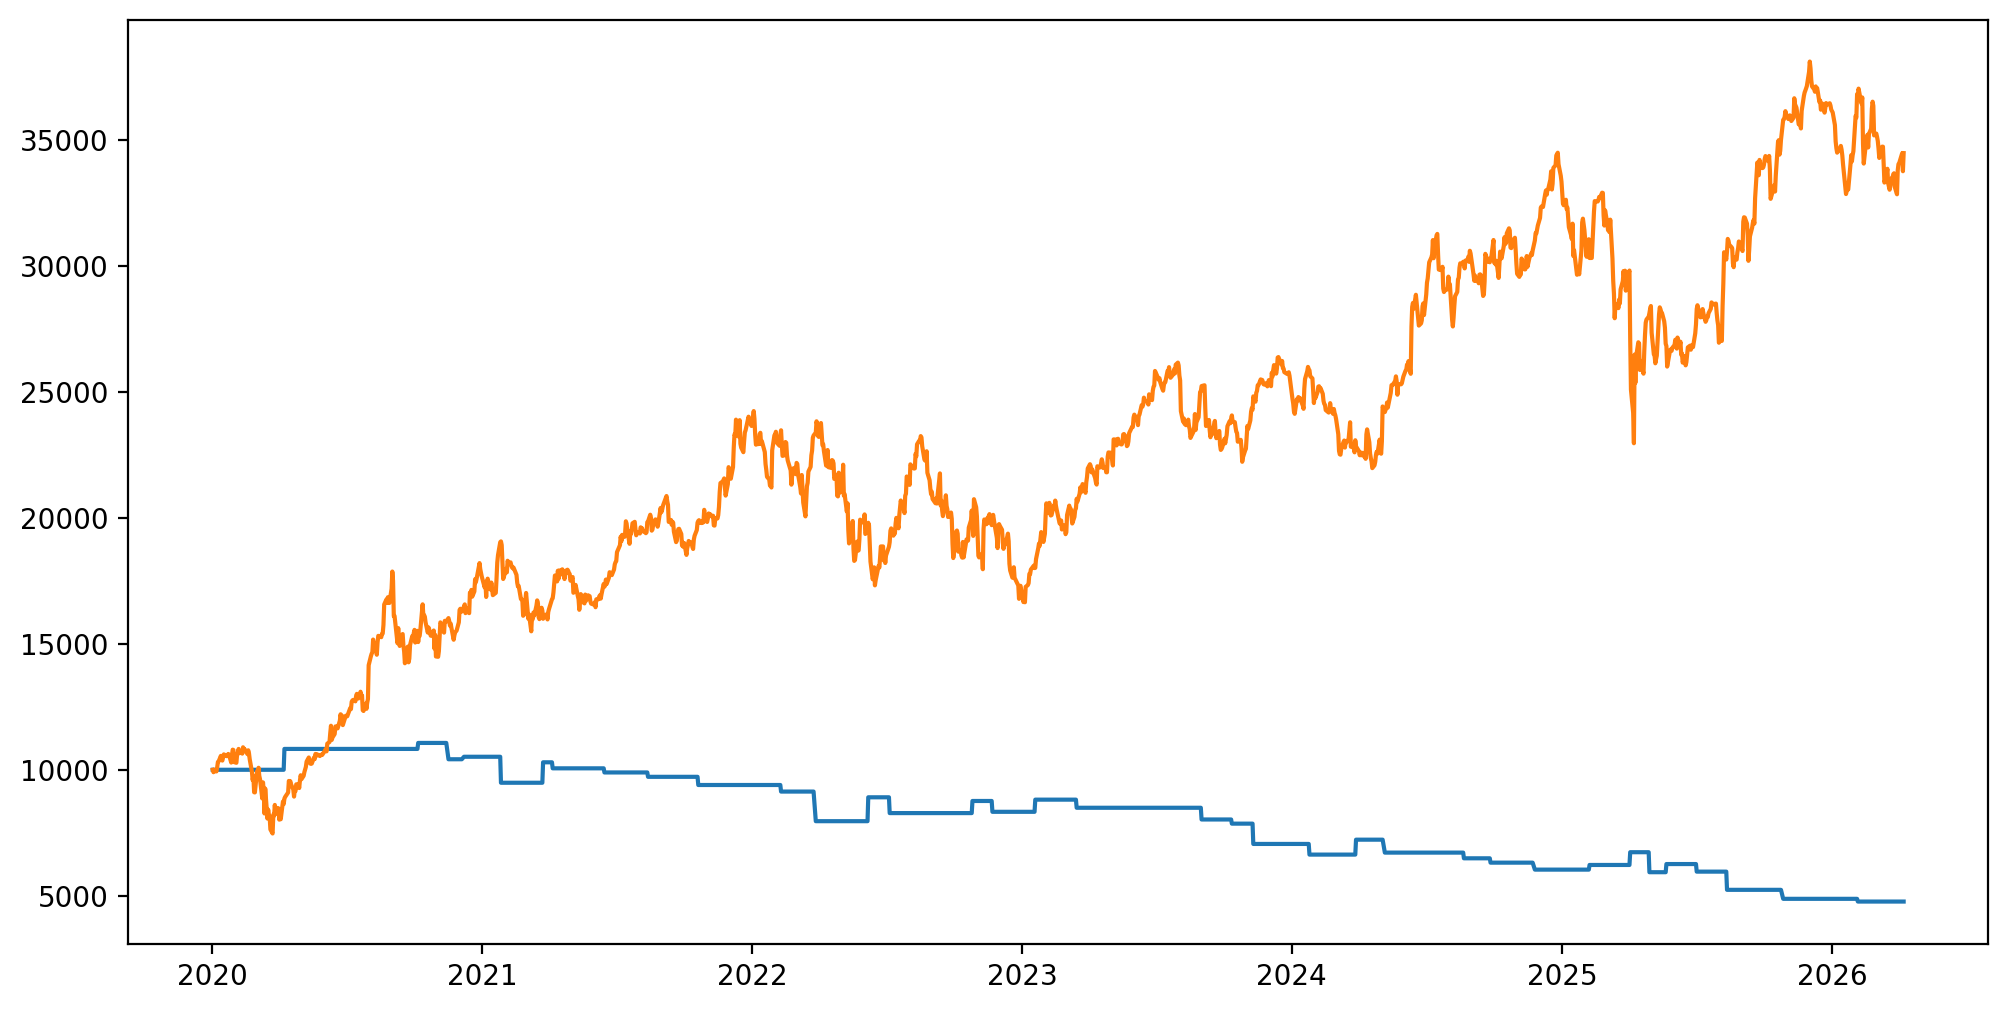

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(report.equity_curve())
plt.show()